<a href="https://colab.research.google.com/github/danhhuit/image-captioning-distillation/blob/main/Tuan02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUẦN 02 - NGUYỄN THÀNH DANH

# 1. Bật GPU

In [17]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


# 2. Mount Drive

In [18]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Corrected path: Assumes 'KLCN' is a folder directly under 'My Drive'
PROJECT = Path("/content/drive/MyDrive/KLCN/NguyenThanhDanh")
DATA_DIR = PROJECT / "data"
CHECKPOINT_DIR = PROJECT / "checkpoints"
CONFIG_DIR = PROJECT / "configs"
FEATURE_DIR = PROJECT / "features"
LOG_DIR = PROJECT / "logs"
METRIC_DIR = PROJECT / "metrics"
PREDICTION_DIR = PROJECT / "predictions"
FIGURE_DIR = PROJECT / "figures"

for directory in [
    CHECKPOINT_DIR, CONFIG_DIR, FEATURE_DIR, LOG_DIR,
    METRIC_DIR, PREDICTION_DIR, FIGURE_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Import thư viện

In [19]:
!pip -q install pycocoevalcap
!pip -q install git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [20]:
import json
import platform
import torch
import torchvision
import pandas as pd
import numpy as np

environment = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
}

print(json.dumps(environment, indent=2, ensure_ascii=False))

with open(CONFIG_DIR / "environment.json", "w", encoding="utf-8") as f:
    json.dump(environment, f, indent=2, ensure_ascii=False)

{
  "python": "3.12.13",
  "torch": "2.11.0+cu128",
  "torchvision": "0.26.0+cu128",
  "cuda_available": true,
  "gpu": "Tesla T4"
}


# 4. Chuẩn bị Flickr8K

4.1. Giải nén vào ổ tạm Colab

In [21]:
import zipfile
from pathlib import Path

ZIP_PATH = DATA_DIR / "Flickr8k.zip"
WORK_DIR = Path("/content/flickr8k")

assert ZIP_PATH.exists(), f"Không tìm thấy: {ZIP_PATH}"

if not WORK_DIR.exists():
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(WORK_DIR)

jpg_files = list(WORK_DIR.rglob("*.jpg"))
print("Số file ảnh tìm thấy:", len(jpg_files))
print("Ví dụ:", jpg_files[:3])

Số file ảnh tìm thấy: 8091
Ví dụ: [PosixPath('/content/flickr8k/Images/2266144051_614b2d62b0.jpg'), PosixPath('/content/flickr8k/Images/3432495898_a5859f06b6.jpg'), PosixPath('/content/flickr8k/Images/3170110692_d1e0e66cee.jpg')]


4.2. Đọc caption

In [22]:
caption_file = next(WORK_DIR.rglob("captions.txt"))
captions_df = pd.read_csv(caption_file)

captions_df.columns = [c.strip().lower() for c in captions_df.columns]
captions_df = captions_df.rename(
    columns={"image_name": "image", "comment": "caption"}
)

captions_df["image"] = captions_df["image"].astype(str).str.strip()
captions_df["caption"] = captions_df["caption"].astype(str).str.strip()

print(captions_df.head())
print("Số dòng caption:", len(captions_df))
print("Số ảnh có caption:", captions_df["image"].nunique())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
Số dòng caption: 40455
Số ảnh có caption: 8091


4.3. Chia train / val / test

In [23]:
def read_split(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

train_file = list(WORK_DIR.rglob("Flickr_8k.trainImages.txt"))
val_file = list(WORK_DIR.rglob("Flickr_8k.devImages.txt"))
test_file = list(WORK_DIR.rglob("Flickr_8k.testImages.txt"))

if train_file and val_file and test_file:
    train_images = read_split(train_file[0])
    val_images = read_split(val_file[0])
    test_images = read_split(test_file[0])
    split_method = "Flickr8K provided split files"
else:
    all_images = sorted(captions_df["image"].unique())

    rng = np.random.default_rng(42)
    rng.shuffle(all_images)

    train_images = all_images[:6000]
    val_images = all_images[6000:7000]
    test_images = all_images[7000:8000]
    split_method = "Deterministic random split, seed=42"

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))
print("Split method:", split_method)

Train: 6000
Validation: 1000
Test: 1000
Split method: Deterministic random split, seed=42


In [24]:
splits = {
    "method": split_method,
    "seed": 42,
    "train": list(train_images),
    "validation": list(val_images),
    "test": list(test_images)
}

with open(CONFIG_DIR / "splits.json", "w", encoding="utf-8") as f:
    json.dump(splits, f, indent=2, ensure_ascii=False)

# 5. Xây dựng Vocabulary

In [25]:
import re
from collections import Counter

PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

MIN_FREQ = 5
MAX_LEN = 30

def tokenize(text):
    text = text.lower().strip()
    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text)

train_caption_df = captions_df[
    captions_df["image"].isin(train_images)
].copy()

counter = Counter()
for caption in train_caption_df["caption"]:
    counter.update(tokenize(caption))

itos = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
itos += sorted([
    token for token, frequency in counter.items()
    if frequency >= MIN_FREQ
])

stoi = {token: index for index, token in enumerate(itos)}

PAD_ID = stoi[PAD_TOKEN]
BOS_ID = stoi[BOS_TOKEN]
EOS_ID = stoi[EOS_TOKEN]
UNK_ID = stoi[UNK_TOKEN]

print("Vocabulary size:", len(itos))

Vocabulary size: 2556


In [26]:
vocab_data = {
    "min_freq": MIN_FREQ,
    "max_len": MAX_LEN,
    "itos": itos,
    "stoi": stoi
}

with open(CONFIG_DIR / "vocabulary.json", "w", encoding="utf-8") as f:
    json.dump(vocab_data, f, indent=2, ensure_ascii=False)

# 6. Tổ chức Visual Encoder

In [27]:
from torch import nn
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    efficientnet_b3,
    EfficientNet_B3_Weights,
    vit_b_16,
    ViT_B_16_Weights
)
import clip

def build_encoder(model_name, device):
    if model_name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        encoder = resnet50(weights=weights)
        encoder.fc = nn.Identity()
        transform = weights.transforms()
        feature_dim = 2048
        weight_name = "ResNet50 IMAGENET1K_V2"

    elif model_name == "efficientnet_b3":
        weights = EfficientNet_B3_Weights.IMAGENET1K_V1
        encoder = efficientnet_b3(weights=weights)
        encoder.classifier = nn.Identity()
        transform = weights.transforms()
        feature_dim = 1536
        weight_name = "EfficientNet-B3 IMAGENET1K_V1"

    elif model_name == "vit_b_16":
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        encoder = vit_b_16(weights=weights)
        encoder.heads = nn.Identity()
        transform = weights.transforms()
        feature_dim = 768
        weight_name = "ViT-B/16 IMAGENET1K_V1"

    elif model_name == "clip_vit_b16":
        clip_model, transform = clip.load(
            "ViT-B/16",
            device="cpu",
            jit=False
        )
        encoder = clip_model.visual
        feature_dim = 512
        weight_name = "OpenAI CLIP ViT-B/16"

    else:
        raise ValueError(f"Model không hợp lệ: {model_name}")

    encoder.eval()

    for parameter in encoder.parameters():
        parameter.requires_grad = False

    encoder = encoder.to(device)
    return encoder, transform, feature_dim, weight_name

In [34]:
import gc
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị:", DEVICE)

MODEL_NAMES = [
    "resnet50",
    "efficientnet_b3",
    "vit_b_16",
    "clip_vit_b16"
]

# Mỗi lần chỉ chạy một model.
MODEL_TO_RUN = "resnet50"


assert MODEL_TO_RUN in MODEL_NAMES
print("Model đang chọn:", MODEL_TO_RUN)

Thiết bị: cuda
Model đang chọn: resnet50


In [125]:
MODEL_TO_RUN = "resnet50"

In [41]:
from PIL import Image
import torch.nn.functional as F

sample_image_path = jpg_files[0]
sample_image = Image.open(sample_image_path).convert("RGB")

encoder, encoder_transform, feature_dim, weight_name = build_encoder(
    MODEL_TO_RUN,
    DEVICE
)

sample_tensor = encoder_transform(sample_image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    sample_feature = encoder(sample_tensor)
    sample_feature = sample_feature.float()
    sample_feature = F.normalize(sample_feature, p=2, dim=-1)

print("Model:", MODEL_TO_RUN)
print("Pretrained weights:", weight_name)
print("Kích thước ảnh sau transform:", sample_tensor.shape)
print("Kích thước feature:", sample_feature.shape)
print("Feature dimension khai báo:", feature_dim)
print("Số tham số encoder:", sum(p.numel() for p in encoder.parameters()))
print("Encoder đã đóng băng:", all(not p.requires_grad for p in encoder.parameters()))

assert sample_feature.ndim == 2
assert sample_feature.shape[0] == 1
assert sample_feature.shape[1] == feature_dim

del encoder, sample_tensor, sample_feature
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

100%|███████████████████████████████████████| 335M/335M [00:03<00:00, 95.3MiB/s]


Model: clip_vit_b16
Pretrained weights: OpenAI CLIP ViT-B/16
Kích thước ảnh sau transform: torch.Size([1, 3, 224, 224])
Kích thước feature: torch.Size([1, 512])
Feature dimension khai báo: 512
Số tham số encoder: 86192640
Encoder đã đóng băng: True


# 7. Trích xuất và cache feature

7.1. Lập bản đồ tên ảnh và kiểm tra split

In [42]:
from pathlib import Path

image_path_by_name = {
    path.name: path
    for path in WORK_DIR.rglob("*.jpg")
}

all_used_images = list(dict.fromkeys(
    list(train_images) +
    list(val_images) +
    list(test_images)
))

missing_images = [
    image_name
    for image_name in all_used_images
    if image_name not in image_path_by_name
]

print("Tổng ảnh trên ổ đĩa:", len(image_path_by_name))
print("Tổng ảnh dùng trong thực nghiệm:", len(all_used_images))
print("Số ảnh bị thiếu:", len(missing_images))

if missing_images:
    print("Một số ảnh bị thiếu:", missing_images[:10])

assert len(all_used_images) == 8000
assert len(missing_images) == 0

Tổng ảnh trên ổ đĩa: 8091
Tổng ảnh dùng trong thực nghiệm: 8000
Số ảnh bị thiếu: 0


7.2. Dataset dùng để trích feature

In [43]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ImageFeatureDataset(Dataset):
    def __init__(self, image_names, image_path_by_name, transform):
        self.image_names = list(image_names)
        self.image_path_by_name = image_path_by_name
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):
        image_name = self.image_names[index]
        image_path = self.image_path_by_name[image_name]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return image, image_name

7.3. Hàm trích xuất feature

In [44]:
import time
import gc
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def extract_and_cache_features(
    model_name,
    batch_size=64,
    force_extract=False
):
    cache_path = FEATURE_DIR / f"{model_name}_features.pt"

    if cache_path.exists() and not force_extract:
        print(f"Đang tải feature cache: {cache_path}")

        feature_pack = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=False
        )

        print("Feature shape:", feature_pack["features"].shape)
        print("Feature dtype:", feature_pack["features"].dtype)
        print("Model:", feature_pack["metadata"]["model_name"])

        assert feature_pack["features"].shape[0] == len(all_used_images)
        return feature_pack

    encoder, transform, feature_dim, weight_name = build_encoder(
        model_name,
        DEVICE
    )

    image_dataset = ImageFeatureDataset(
        image_names=all_used_images,
        image_path_by_name=image_path_by_name,
        transform=transform
    )

    image_loader = DataLoader(
        image_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    all_features = []
    extracted_image_names = []

    encoder_parameter_count = sum(
        parameter.numel()
        for parameter in encoder.parameters()
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    encoder.eval()

    with torch.inference_mode():
        for images, image_names in tqdm(
            image_loader,
            desc=f"Extracting {model_name}"
        ):
            images = images.to(
                DEVICE,
                non_blocking=True
            )

            features = encoder(images)

            # CLIP có thể trả float16; chuyển về float32 trước khi normalize.
            features = features.float()
            features = F.normalize(features, p=2, dim=-1)

            # Lưu float16 để giảm dung lượng file.
            all_features.append(features.cpu().half())
            extracted_image_names.extend(list(image_names))

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    extraction_seconds = time.perf_counter() - start_time

    feature_tensor = torch.cat(all_features, dim=0)

    assert feature_tensor.shape[0] == len(all_used_images)
    assert feature_tensor.shape[1] == feature_dim
    assert extracted_image_names == all_used_images

    metadata = {
        "model_name": model_name,
        "weight_name": weight_name,
        "feature_dim": feature_dim,
        "number_of_images": len(extracted_image_names),
        "encoder_parameter_count": encoder_parameter_count,
        "extraction_seconds": extraction_seconds,
        "feature_normalization": "L2",
        "encoder_frozen": True,
        "split_method": split_method
    }

    feature_pack = {
        "image_names": extracted_image_names,
        "features": feature_tensor,
        "metadata": metadata
    }

    torch.save(feature_pack, cache_path)

    print("\nĐã lưu:", cache_path)
    print("Feature shape:", feature_tensor.shape)
    print("Feature dtype:", feature_tensor.dtype)
    print("Thời gian trích xuất:", round(extraction_seconds, 2), "giây")
    print("Dung lượng:", round(cache_path.stat().st_size / 1024**2, 2), "MB")

    del encoder
    del all_features
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return feature_pack

7.4. Trích xuất feature cho model đang chọn

In [126]:
feature_pack = extract_and_cache_features(
    MODEL_TO_RUN,
    batch_size=64,
    force_extract=True
)

print(json.dumps(
    feature_pack["metadata"],
    indent=2,
    ensure_ascii=False
))

Extracting resnet50:   0%|          | 0/125 [00:00<?, ?it/s]


Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/features/resnet50_features.pt
Feature shape: torch.Size([8000, 2048])
Feature dtype: torch.float16
Thời gian trích xuất: 72.14 giây
Dung lượng: 31.52 MB
{
  "model_name": "resnet50",
  "weight_name": "ResNet50 IMAGENET1K_V2",
  "feature_dim": 2048,
  "number_of_images": 8000,
  "encoder_parameter_count": 23508032,
  "extraction_seconds": 72.141978620999,
  "feature_normalization": "L2",
  "encoder_frozen": true,
  "split_method": "Deterministic random split, seed=42"
}


# 8. Dataset caption và Transformer Decorder

8.1. Tạo dictionary caption theo ảnh

In [47]:
captions_by_image = (
    captions_df
    .groupby("image")["caption"]
    .apply(list)
    .to_dict()
)

print("Số ảnh trong captions_by_image:", len(captions_by_image))
print("Ví dụ:")
print(all_used_images[0])
print(captions_by_image[all_used_images[0]])

Số ảnh trong captions_by_image: 8091
Ví dụ:
3241892328_4ebf8b21ce.jpg
['A female lionist jumping in a green field with a green mountain in the background .', 'A lion jumping through tall grass .', 'A mountain lion is leaping off of a rock .', 'a tiger jumps off a rock .', 'Cougar pouncing off rock .']


8.2. Chuyển caption thành token ID

In [48]:
def encode_caption(caption):
    tokens = tokenize(caption)

    # Chừa hai vị trí cho BOS và EOS.
    tokens = tokens[:MAX_LEN - 2]

    token_ids = [
        stoi.get(token, UNK_ID)
        for token in tokens
    ]

    token_ids = [BOS_ID] + token_ids + [EOS_ID]

    return torch.tensor(
        token_ids,
        dtype=torch.long
    )

def decode_token_ids(token_ids):
    words = []

    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == EOS_ID:
            break

        if token_id in [PAD_ID, BOS_ID]:
            continue

        words.append(itos[token_id])

    return " ".join(words)

In [49]:
#check
example_caption = captions_df.iloc[0]["caption"]
example_ids = encode_caption(example_caption)

print("Caption:", example_caption)
print("Token IDs:", example_ids.tolist())
print("Khôi phục:", decode_token_ids(example_ids.tolist()))

Caption: A child in a pink dress is climbing up a set of stairs in an entry way .
Token IDs: [1, 11, 436, 1100, 11, 1600, 658, 1125, 465, 2414, 11, 1891, 1442, 2105, 1100, 51, 3, 2481, 2]
Khôi phục: a child in a pink dress is climbing up a set of stairs in an <unk> way


8.3. Dataset huấn luyện từ feature cache

In [50]:
class FeatureCaptionDataset(Dataset):
    def __init__(
        self,
        feature_pack,
        selected_image_names,
        captions_by_image
    ):
        self.feature_tensor = feature_pack["features"]

        self.feature_index = {
            image_name: index
            for index, image_name
            in enumerate(feature_pack["image_names"])
        }

        self.samples = []

        for image_name in selected_image_names:
            for caption in captions_by_image[image_name]:
                self.samples.append((image_name, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_name, caption = self.samples[index]
        feature_index = self.feature_index[image_name]

        # Feature lưu float16; decoder huấn luyện float32/AMP.
        feature = self.feature_tensor[feature_index].float()
        caption_ids = encode_caption(caption)

        return feature, caption_ids, image_name

8.4. Hàm padding batch

In [51]:
from torch.nn.utils.rnn import pad_sequence

def caption_collate_fn(batch):
    features, captions, image_names = zip(*batch)

    features = torch.stack(features, dim=0)

    captions = pad_sequence(
        captions,
        batch_first=True,
        padding_value=PAD_ID
    )

    return features, captions, list(image_names)

8.5. Tạo DataLoader

In [103]:
def create_caption_loaders(
    feature_pack,
    batch_size=128
):
    train_dataset = FeatureCaptionDataset(
        feature_pack=feature_pack,
        selected_image_names=train_images,
        captions_by_image=captions_by_image
    )

    val_dataset = FeatureCaptionDataset(
        feature_pack=feature_pack,
        selected_image_names=val_images,
        captions_by_image=captions_by_image
    )

    data_generator = torch.Generator()
    data_generator.manual_seed(42)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=caption_collate_fn,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=data_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=caption_collate_fn,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    print("Train samples:", len(train_dataset))
    print("Validation samples:", len(val_dataset))
    print("Train batches:", len(train_loader))
    print("Validation batches:", len(val_loader))

    return train_loader, val_loader

In [129]:
train_loader, val_loader = create_caption_loaders(
    feature_pack,
    batch_size=128
)

Train samples: 30000
Validation samples: 5000
Train batches: 235
Validation batches: 40


In [105]:
# check 1 batch
features_batch, captions_batch, image_names_batch = next(
    iter(train_loader)
)

print("Feature batch:", features_batch.shape)
print("Caption batch:", captions_batch.shape)
print("Ảnh đầu tiên:", image_names_batch[0])
print("Caption đầu tiên:", decode_token_ids(captions_batch[0].tolist()))

Feature batch: torch.Size([128, 512])
Caption batch: torch.Size([128, 30])
Ảnh đầu tiên: 3212085754_35fdc9ccaa.jpg
Caption đầu tiên: a <unk> wearing a red dress is putting the bride s shoe on her foot


8.6. Định nghĩa Transformer Decoder

In [55]:
import math
import torch
from torch import nn

class ImageCaptionTransformer(nn.Module):
    def __init__(
        self,
        feature_dim,
        vocab_size,
        d_model=256,
        nhead=8,
        num_layers=3,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=30,
        pad_id=0
    ):
        super().__init__()

        self.feature_dim = feature_dim
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len
        self.pad_id = pad_id

        # Chuyển feature của encoder về cùng d_model.
        self.image_projection = nn.Sequential(
            nn.Linear(feature_dim, d_model),
            nn.LayerNorm(d_model)
        )

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.position_embedding = nn.Embedding(
            max_len,
            d_model
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def create_causal_mask(self, sequence_length, device):
        # True nghĩa là vị trí bị che.
        return torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=device
            ),
            diagonal=1
        )

    def forward(self, image_features, input_token_ids):
        """
        image_features:
            [batch_size, feature_dim]

        input_token_ids:
            [batch_size, sequence_length]
        """

        batch_size, sequence_length = input_token_ids.shape

        if sequence_length > self.max_len:
            raise ValueError(
                f"Sequence length {sequence_length} "
                f"lớn hơn max_len={self.max_len}"
            )

        # Một global image feature được xem là một memory token.
        memory = self.image_projection(image_features)
        memory = memory.unsqueeze(1)
        # [batch_size, 1, d_model]

        positions = torch.arange(
            sequence_length,
            device=input_token_ids.device
        ).unsqueeze(0)

        token_embeddings = self.token_embedding(input_token_ids)
        position_embeddings = self.position_embedding(positions)

        target_embeddings = (
            token_embeddings * math.sqrt(self.d_model)
            + position_embeddings
        )

        target_embeddings = self.dropout(target_embeddings)

        causal_mask = self.create_causal_mask(
            sequence_length,
            input_token_ids.device
        )

        padding_mask = input_token_ids.eq(self.pad_id)

        decoder_output = self.decoder(
            tgt=target_embeddings,
            memory=memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=padding_mask
        )

        logits = self.output_layer(decoder_output)

        return logits

8.7. Tạo cấu hình model

In [56]:
feature_dim = int(feature_pack["metadata"]["feature_dim"])

model_config = {
    "feature_dim": feature_dim,
    "vocab_size": len(itos),
    "d_model": 256,
    "nhead": 8,
    "num_layers": 3,
    "dim_feedforward": 1024,
    "dropout": 0.1,
    "max_len": MAX_LEN,
    "pad_id": PAD_ID
}

model = ImageCaptionTransformer(
    **model_config
).to(DEVICE)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print("Trainable parameters:", f"{trainable_parameter_count:,}")

ImageCaptionTransformer(
  (image_projection): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (token_embedding): Embedding(2556, 256, padding_idx=0)
  (position_embedding): Embedding(30, 256)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps

8.8. Kiểm tra forward

In [57]:
features_batch = features_batch.to(DEVICE)
captions_batch = captions_batch.to(DEVICE)

# Input bỏ token cuối.
caption_inputs = captions_batch[:, :-1]

with torch.no_grad():
    logits = model(
        features_batch,
        caption_inputs
    )

print("Input caption shape:", caption_inputs.shape)
print("Logits shape:", logits.shape)

assert logits.shape[0] == caption_inputs.shape[0]
assert logits.shape[1] == caption_inputs.shape[1]
assert logits.shape[2] == len(itos)

Input caption shape: torch.Size([128, 29])
Logits shape: torch.Size([128, 29, 2556])


# 9. Huấn luyện, validation, early stopping và lưu checkpoint

9.1. Đặt seed

In [58]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

9.2. Hàm chạy 1 epoch

In [59]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    scaler
):
    model.train()

    total_loss_sum = 0.0
    total_token_count = 0

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for features, captions, _ in progress_bar:
        features = features.to(
            DEVICE,
            non_blocking=True
        )

        captions = captions.to(
            DEVICE,
            non_blocking=True
        )

        # Teacher forcing:
        # input  = <bos> a dog is running
        # target = a dog is running <eos>
        input_ids = captions[:, :-1]
        target_ids = captions[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        use_amp = DEVICE.type == "cuda"

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=use_amp
        ):
            logits = model(features, input_ids)

            loss_sum = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )

            valid_token_count = (
                target_ids != PAD_ID
            ).sum()

            loss = loss_sum / valid_token_count.clamp_min(1)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss_sum += float(loss_sum.detach().item())
        total_token_count += int(valid_token_count.item())

        average_loss = total_loss_sum / max(total_token_count, 1)

        progress_bar.set_postfix(
            loss=f"{average_loss:.4f}"
        )

    return total_loss_sum / max(total_token_count, 1)

9.3. Hàm validation

In [60]:
@torch.inference_mode()
def validate_one_epoch(
    model,
    data_loader,
    criterion
):
    model.eval()

    total_loss_sum = 0.0
    total_token_count = 0

    progress_bar = tqdm(
        data_loader,
        desc="Validation",
        leave=False
    )

    for features, captions, _ in progress_bar:
        features = features.to(
            DEVICE,
            non_blocking=True
        )

        captions = captions.to(
            DEVICE,
            non_blocking=True
        )

        input_ids = captions[:, :-1]
        target_ids = captions[:, 1:]

        use_amp = DEVICE.type == "cuda"

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=use_amp
        ):
            logits = model(features, input_ids)

            loss_sum = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_ids.reshape(-1)
            )

        valid_token_count = (
            target_ids != PAD_ID
        ).sum()

        total_loss_sum += float(loss_sum.item())
        total_token_count += int(valid_token_count.item())

        average_loss = total_loss_sum / max(total_token_count, 1)

        progress_bar.set_postfix(
            loss=f"{average_loss:.4f}"
        )

    return total_loss_sum / max(total_token_count, 1)

9.4. Hàm lưu checkpoint

In [61]:
def make_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    train_loss,
    val_loss,
    model_name,
    model_config,
    history
):
    return {
        "model_name": model_name,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "vocabulary": vocab_data,
        "model_config": model_config,
        "environment": environment,
        "feature_metadata": feature_pack["metadata"],
        "split_method": split_method,
        "history": history
    }

9.5. Hàm huấn luyện toàn bộ

In [62]:
import time
import pandas as pd
from copy import deepcopy

def train_selected_model(
    model_name,
    feature_pack,
    train_loader,
    val_loader,
    max_epochs=20,
    learning_rate=3e-4,
    weight_decay=1e-4,
    early_stopping_patience=4
):
    set_seed(42)

    feature_dim = int(
        feature_pack["metadata"]["feature_dim"]
    )

    current_model_config = {
        "feature_dim": feature_dim,
        "vocab_size": len(itos),
        "d_model": 256,
        "nhead": 8,
        "num_layers": 3,
        "dim_feedforward": 1024,
        "dropout": 0.1,
        "max_len": MAX_LEN,
        "pad_id": PAD_ID
    }

    model = ImageCaptionTransformer(
        **current_model_config
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    # reduction="sum" để tính loss trung bình chính xác theo token.
    criterion = nn.CrossEntropyLoss(
        ignore_index=PAD_ID,
        reduction="sum"
    )

    scaler = torch.amp.GradScaler(
        DEVICE.type,
        enabled=(DEVICE.type == "cuda")
    )

    best_checkpoint_path = (
        CHECKPOINT_DIR / f"{model_name}_best.pth"
    )

    last_checkpoint_path = (
        CHECKPOINT_DIR / f"{model_name}_last.pth"
    )

    log_path = LOG_DIR / f"{model_name}_history.csv"

    history = []
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_start_time = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        epoch_start_time = time.perf_counter()

        current_lr = optimizer.param_groups[0]["lr"]

        train_loss = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler
        )

        val_loss = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )

        scheduler.step(val_loss)

        epoch_seconds = time.perf_counter() - epoch_start_time

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": current_lr,
            "epoch_seconds": epoch_seconds
        }

        history.append(epoch_record)

        history_df = pd.DataFrame(history)
        history_df.to_csv(
            log_path,
            index=False
        )

        checkpoint = make_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            train_loss=train_loss,
            val_loss=val_loss,
            model_name=model_name,
            model_config=current_model_config,
            history=deepcopy(history)
        )

        # Luôn lưu checkpoint cuối.
        torch.save(
            checkpoint,
            last_checkpoint_path
        )

        improved = val_loss < best_val_loss - 1e-4

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                checkpoint,
                best_checkpoint_path
            )

            status = "Đã lưu BEST checkpoint"
        else:
            epochs_without_improvement += 1
            status = (
                f"Không cải thiện "
                f"{epochs_without_improvement}/"
                f"{early_stopping_patience}"
            )

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"lr={current_lr:.2e} | "
            f"time={epoch_seconds:.1f}s | "
            f"{status}"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"Early stopping tại epoch {epoch}. "
                f"Best epoch = {best_epoch}"
            )
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_seconds = time.perf_counter() - training_start_time

    # Tải checkpoint tốt nhất.
    best_checkpoint = torch.load(
        best_checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    # Bổ sung tổng thời gian vào checkpoint tốt nhất.
    best_checkpoint["training_seconds"] = training_seconds
    best_checkpoint["best_epoch"] = best_epoch
    best_checkpoint["best_val_loss"] = best_val_loss
    best_checkpoint["history"] = history

    torch.save(
        best_checkpoint,
        best_checkpoint_path
    )

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[
        history_df["val_loss"].idxmin()
    ]

    print("\n===== HOÀN THÀNH HUẤN LUYỆN =====")
    print("Model:", model_name)
    print("Best epoch:", int(best_row["epoch"]))
    print("Training loss tại best epoch:", best_row["train_loss"])
    print("Validation loss tốt nhất:", best_row["val_loss"])
    print("Thời gian huấn luyện:", round(training_seconds, 2), "giây")
    print("Best checkpoint:", best_checkpoint_path)
    print("Last checkpoint:", last_checkpoint_path)
    print("Log:", log_path)

    return model, history_df, best_checkpoint

9.6. Chạy huấn luyện theo model đã chọn

In [130]:
model, history_df, best_checkpoint = train_selected_model(
    model_name=MODEL_TO_RUN,
    feature_pack=feature_pack,
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=20,
    learning_rate=3e-4,
    weight_decay=1e-4,
    early_stopping_patience=4
)

Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=4.6835 | val_loss=3.7813 | lr=3.00e-04 | time=7.1s | Đã lưu BEST checkpoint


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 07/20 | train_loss=3.5194 | val_loss=3.3482 | lr=3.00e-04 | time=8.9s | Không cải thiện 3/4


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 08/20 | train_loss=3.4012 | val_loss=3.3282 | lr=1.50e-04 | time=7.9s | Không cải thiện 4/4
Early stopping tại epoch 8. Best epoch = 4

===== HOÀN THÀNH HUẤN LUYỆN =====
Model: resnet50
Best epoch: 4
Training loss tại best epoch: 3.053661819217832
Validation loss tốt nhất: 3.041796218017549
Thời gian huấn luyện: 79.3 giây
Best checkpoint: /content/drive/MyDrive/KLCN/NguyenThanhDanh/checkpoints/resnet50_best.pth
Last checkpoint: /content/drive/MyDrive/KLCN/NguyenThanhDanh/checkpoints/resnet50_last.pth
Log: /content/drive/MyDrive/KLCN/NguyenThanhDanh/logs/resnet50_history.csv


9.7. Vẽ loss

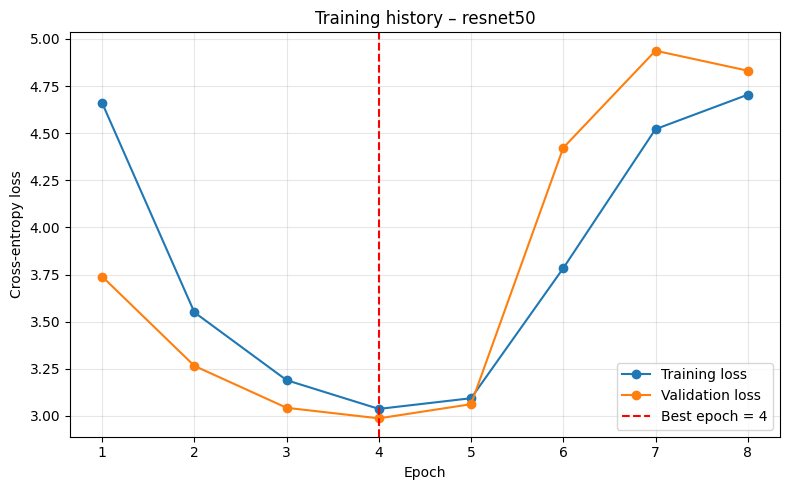

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/figures/resnet50_loss.png


In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

best_epoch = int(
    history_df.loc[
        history_df["val_loss"].idxmin(),
        "epoch"
    ]
)

plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"Training history – {MODEL_TO_RUN}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

loss_figure_path = (
    FIGURE_DIR / f"{MODEL_TO_RUN}_loss.png"
)

plt.savefig(
    loss_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu:", loss_figure_path)

# 10. Tải lại và kiểm tra checkpoint

10.1. Hàm tải model từ checkpoint

In [107]:
def load_caption_model_from_checkpoint(model_name):
    checkpoint_path = (
        CHECKPOINT_DIR / f"{model_name}_best.pth"
    )

    assert checkpoint_path.exists(), (
        f"Không tìm thấy checkpoint: {checkpoint_path}"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    loaded_model = ImageCaptionTransformer(
        **checkpoint["model_config"]
    ).to(DEVICE)

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    loaded_model.eval()

    print("Đã tải checkpoint:", checkpoint_path)
    print("Model:", checkpoint["model_name"])
    print("Epoch tốt nhất:", checkpoint["epoch"])
    print("Train loss tại best epoch:", checkpoint["train_loss"])
    print("Validation loss tại best epoch:", checkpoint["val_loss"])
    print(
        "Vocabulary size trong checkpoint:",
        len(checkpoint["vocabulary"]["itos"])
    )

    assert checkpoint["model_name"] == model_name
    assert (
        len(checkpoint["vocabulary"]["itos"])
        == len(itos)
    )

    return loaded_model, checkpoint

In [108]:
# run
loaded_model, loaded_checkpoint = (
    load_caption_model_from_checkpoint(MODEL_TO_RUN)
)

Đã tải checkpoint: /content/drive/MyDrive/KLCN/NguyenThanhDanh/checkpoints/clip_vit_b16_best.pth
Model: clip_vit_b16
Epoch tốt nhất: 4
Train loss tại best epoch: 3.036639707632043
Validation loss tại best epoch: 2.9865819448636213
Vocabulary size trong checkpoint: 2556


10.2. So sánh trọng số trước và sau khi tải

In [68]:
same_weights = True

for current_parameter, loaded_parameter in zip(
    model.parameters(),
    loaded_model.parameters()
):
    if not torch.allclose(
        current_parameter.detach().cpu(),
        loaded_parameter.detach().cpu(),
        atol=1e-6
    ):
        same_weights = False
        break

print("Trọng số giống nhau:", same_weights)
assert same_weights

Trọng số giống nhau: True


# 11. Greedy, beam search, sinh caption và tính metrics

11.1. Greedy decoding

In [69]:
@torch.inference_mode()
def greedy_decode(
    model,
    image_feature,
    max_len=MAX_LEN
):
    model.eval()

    image_feature = image_feature.float()
    image_feature = image_feature.unsqueeze(0).to(DEVICE)

    generated_ids = torch.tensor(
        [[BOS_ID]],
        dtype=torch.long,
        device=DEVICE
    )

    for step in range(max_len - 1):
        logits = model(
            image_feature,
            generated_ids
        )

        next_token_logits = logits[:, -1, :].clone()

        # Không cho sinh PAD hoặc BOS.
        next_token_logits[:, PAD_ID] = float("-inf")
        next_token_logits[:, BOS_ID] = float("-inf")

        # Không kết thúc quá sớm.
        if generated_ids.shape[1] < 3:
            next_token_logits[:, EOS_ID] = float("-inf")

        next_token_id = torch.argmax(
            next_token_logits,
            dim=-1,
            keepdim=True
        )

        generated_ids = torch.cat(
            [generated_ids, next_token_id],
            dim=1
        )

        if int(next_token_id.item()) == EOS_ID:
            break

    token_ids = generated_ids.squeeze(0).tolist()

    return decode_token_ids(token_ids), token_ids

11.2. Beam search

In [70]:
import torch.nn.functional as F

def beam_length_score(
    accumulated_log_probability,
    token_count,
    alpha=0.7
):
    effective_length = max(token_count - 1, 1)

    return (
        accumulated_log_probability
        / (effective_length ** alpha)
    )

@torch.inference_mode()
def beam_search_decode(
    model,
    image_feature,
    beam_size=3,
    max_len=MAX_LEN,
    length_penalty_alpha=0.7
):
    model.eval()

    image_feature = image_feature.float()
    image_feature = image_feature.unsqueeze(0).to(DEVICE)

    # Mỗi beam:
    # (token_ids, accumulated_log_probability, finished)
    beams = [
        ([BOS_ID], 0.0, False)
    ]

    for step in range(max_len - 1):
        candidates = []

        for token_ids, score, finished in beams:
            if finished:
                candidates.append(
                    (token_ids, score, True)
                )
                continue

            input_ids = torch.tensor(
                [token_ids],
                dtype=torch.long,
                device=DEVICE
            )

            logits = model(
                image_feature,
                input_ids
            )

            next_token_logits = logits[0, -1].clone()

            next_token_logits[PAD_ID] = float("-inf")
            next_token_logits[BOS_ID] = float("-inf")

            if len(token_ids) < 3:
                next_token_logits[EOS_ID] = float("-inf")

            log_probabilities = F.log_softmax(
                next_token_logits,
                dim=-1
            )

            top_log_probs, top_token_ids = torch.topk(
                log_probabilities,
                k=beam_size
            )

            for log_probability, token_id in zip(
                top_log_probs.tolist(),
                top_token_ids.tolist()
            ):
                new_token_ids = token_ids + [token_id]
                new_score = score + log_probability
                new_finished = token_id == EOS_ID

                candidates.append(
                    (
                        new_token_ids,
                        new_score,
                        new_finished
                    )
                )

        candidates.sort(
            key=lambda item: beam_length_score(
                item[1],
                len(item[0]),
                alpha=length_penalty_alpha
            ),
            reverse=True
        )

        beams = candidates[:beam_size]

        if all(finished for _, _, finished in beams):
            break

    best_tokens, best_score, _ = max(
        beams,
        key=lambda item: beam_length_score(
            item[1],
            len(item[0]),
            alpha=length_penalty_alpha
        )
    )

    caption = decode_token_ids(best_tokens)

    return caption, best_tokens, best_score

11.3. Lấy feature theo tên ảnh

In [71]:
feature_index_by_image = {
    image_name: index
    for index, image_name
    in enumerate(feature_pack["image_names"])
}

def get_image_feature(image_name):
    feature_index = feature_index_by_image[image_name]
    return feature_pack["features"][feature_index].float()

11.4. Thử trên một ảnh test

In [72]:
test_image_name = test_images[0]
test_feature = get_image_feature(test_image_name)

greedy_caption, greedy_ids = greedy_decode(
    loaded_model,
    test_feature
)

beam_caption, beam_ids, beam_score = beam_search_decode(
    loaded_model,
    test_feature,
    beam_size=3
)

print("Tên ảnh:", test_image_name)

print("\nCaption tham chiếu:")
for index, reference in enumerate(
    captions_by_image[test_image_name],
    start=1
):
    print(f"{index}. {reference}")

print("\nGreedy:")
print(greedy_caption)

print("\nBeam search:")
print(beam_caption)

print("\nBeam score:")
print(beam_score)

Tên ảnh: 2736508369_fd9ff0b42f.jpg

Caption tham chiếu:
1. A baseball player is tagged out sliding into second base .
2. A baseball player slides toward a base .
3. a man in a grey uniform sliding into a base
4. Three men playing baseball .
5. two fielder are defending the base as a member of the batting team slide towards it .

Greedy:
a man in a red uniform is playing basketball

Beam search:
a football player in a red uniform is playing basketball

Beam score:
-14.038578748703003


11.5. Sinh caption cho toàn bộ test set

In [109]:
import time
import json
from tqdm.auto import tqdm

def generate_test_predictions(
    model,
    feature_pack,
    model_name,
    method="beam",
    beam_size=3
):
    feature_index = {
        image_name: index
        for index, image_name
        in enumerate(feature_pack["image_names"])
    }

    predictions = {}

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    for image_name in tqdm(
        test_images,
        desc=f"Generating {model_name}"
    ):
        feature = feature_pack["features"][
            feature_index[image_name]
        ].float()

        if method == "beam":
            caption, _, _ = beam_search_decode(
                model,
                feature,
                beam_size=beam_size
            )
        elif method == "greedy":
            caption, _ = greedy_decode(
                model,
                feature
            )
        else:
            raise ValueError(
                "method phải là 'beam' hoặc 'greedy'"
            )

        predictions[image_name] = caption

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_seconds = time.perf_counter() - start_time

    output_data = {
        "model_name": model_name,
        "decoding_method": method,
        "beam_size": beam_size if method == "beam" else 1,
        "number_of_images": len(predictions),
        "inference_seconds": inference_seconds,
        "average_seconds_per_image": (
            inference_seconds / len(predictions)
        ),
        "predictions": predictions
    }

    prediction_path = (
        PREDICTION_DIR /
        f"{model_name}_{method}_predictions.json"
    )

    with open(
        prediction_path,
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            output_data,
            f,
            indent=2,
            ensure_ascii=False
        )

    print("Đã lưu:", prediction_path)
    print("Số caption:", len(predictions))
    print(
        "Tổng thời gian suy luận:",
        round(inference_seconds, 2),
        "giây"
    )
    print(
        "Trung bình mỗi ảnh:",
        round(inference_seconds / len(predictions), 4),
        "giây"
    )

    return predictions, inference_seconds

In [110]:
test_predictions, inference_seconds = (
    generate_test_predictions(
        model=loaded_model,
        feature_pack=feature_pack,
        model_name=MODEL_TO_RUN,
        method="beam",
        beam_size=3
    )
)

Generating clip_vit_b16:   0%|          | 0/1000 [00:00<?, ?it/s]

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/predictions/clip_vit_b16_beam_predictions.json
Số caption: 1000
Tổng thời gian suy luận: 127.91 giây
Trung bình mỗi ảnh: 0.1279 giây


11.6. Tính BLEU, METEOR, ROUGE-L và CIDEr

In [111]:
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def calculate_caption_metrics(predictions):
    ground_truth_raw = {}
    predictions_raw = {}

    for image_id, image_name in enumerate(test_images):
        references = captions_by_image[image_name]
        prediction = predictions[image_name]

        ground_truth_raw[image_id] = [
            {"caption": reference}
            for reference in references
        ]

        predictions_raw[image_id] = [
            {"caption": prediction}
        ]

    print("Đang chạy PTBTokenizer...")

    tokenizer = PTBTokenizer()

    ground_truth = tokenizer.tokenize(
        ground_truth_raw
    )

    prediction_tokens = tokenizer.tokenize(
        predictions_raw
    )

    metrics = {}

    print("Đang tính BLEU...")
    bleu_scorer = Bleu(4)

    bleu_scores, _ = bleu_scorer.compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["BLEU-1"] = float(bleu_scores[0])
    metrics["BLEU-2"] = float(bleu_scores[1])
    metrics["BLEU-3"] = float(bleu_scores[2])
    metrics["BLEU-4"] = float(bleu_scores[3])

    print("Đang tính METEOR...")
    meteor_scorer = Meteor()

    try:
        meteor_score, _ = meteor_scorer.compute_score(
            ground_truth,
            prediction_tokens
        )
        metrics["METEOR"] = float(meteor_score)
    finally:
        if hasattr(meteor_scorer, "close"):
            meteor_scorer.close()

    print("Đang tính ROUGE-L...")
    rouge_score, _ = Rouge().compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["ROUGE-L"] = float(rouge_score)

    print("Đang tính CIDEr...")
    cider_score, _ = Cider().compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["CIDEr"] = float(cider_score)

    return metrics

In [112]:
metrics = calculate_caption_metrics(
    test_predictions
)

metrics.update({
    "model_name": MODEL_TO_RUN,
    "decoding_method": "beam",
    "beam_size": 3,
    "inference_seconds": inference_seconds,
    "average_seconds_per_image": (
        inference_seconds / len(test_images)
    ),
    "best_epoch": int(
        loaded_checkpoint["epoch"]
    ),
    "train_loss_at_best_epoch": float(
        loaded_checkpoint["train_loss"]
    ),
    "validation_loss_at_best_epoch": float(
        loaded_checkpoint["val_loss"]
    ),
    "feature_extraction_seconds": float(
        feature_pack["metadata"]["extraction_seconds"]
    ),
    "training_seconds": float(
        loaded_checkpoint["training_seconds"]
    )
})

metric_path = (
    METRIC_DIR /
    f"{MODEL_TO_RUN}_beam_metrics.json"
)

with open(
    metric_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n===== KẾT QUẢ =====")

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

print("\nĐã lưu:", metric_path)

Đang chạy PTBTokenizer...
Đang tính BLEU...
{'testlen': 10006, 'reflen': 9806, 'guess': [10006, 9006, 8006, 7006], 'correct': [6388, 2812, 1107, 400]}
ratio: 1.0203956761165591
Đang tính METEOR...
Đang tính ROUGE-L...
Đang tính CIDEr...

===== KẾT QUẢ =====
BLEU-1: 0.638417
BLEU-2: 0.446472
BLEU-3: 0.302069
BLEU-4: 0.199172
METEOR: 0.202404
ROUGE-L: 0.471230
CIDEr: 0.499591
model_name: clip_vit_b16
decoding_method: beam
beam_size: 3
inference_seconds: 127.909862
average_seconds_per_image: 0.127910
best_epoch: 4
train_loss_at_best_epoch: 3.036640
validation_loss_at_best_epoch: 2.986582
feature_extraction_seconds: 155.599431
training_seconds: 66.116060

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/clip_vit_b16_beam_metrics.json


# 12. Tính chỉ số trên tập kiểm thử

12.1. Kiểm tra đủ checkpoint và feature của bốn mô hình

In [114]:
from pathlib import Path

REQUIRED_MODELS = [
    "resnet50",
    "efficientnet_b3",
    "vit_b_16",
    "clip_vit_b16"
]

def check_evaluation_assets(model_names):
    missing_assets = []

    for model_name in model_names:
        checkpoint_path = (
            CHECKPOINT_DIR / f"{model_name}_best.pth"
        )

        feature_path = (
            FEATURE_DIR / f"{model_name}_features.pt"
        )

        if not checkpoint_path.exists():
            missing_assets.append(str(checkpoint_path))

        if not feature_path.exists():
            missing_assets.append(str(feature_path))

    if missing_assets:
        print("Thiếu các file sau:")

        for path in missing_assets:
            print("-", path)

        raise FileNotFoundError(
            "Phải huấn luyện/trích feature đủ bốn model trước khi đánh giá."
        )

    print("Đã có đủ checkpoint và feature của bốn mô hình.")

check_evaluation_assets(REQUIRED_MODELS)

Đã có đủ checkpoint và feature của bốn mô hình.


12.2. Hàm tạo mã kiểm tra dữ liệu

In [115]:
import hashlib
import json

def dictionary_fingerprint(data):
    canonical_text = json.dumps(
        data,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":")
    )

    return hashlib.sha256(
        canonical_text.encode("utf-8")
    ).hexdigest()

def file_sha256(file_path, chunk_size=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

12.3. Tải đúng checkpoint và feature của từng model

In [116]:
import torch

def load_evaluation_assets(model_name):
    checkpoint_path = (
        CHECKPOINT_DIR / f"{model_name}_best.pth"
    )

    feature_path = (
        FEATURE_DIR / f"{model_name}_features.pt"
    )

    assert checkpoint_path.exists(), (
        f"Không tìm thấy checkpoint: {checkpoint_path}"
    )

    assert feature_path.exists(), (
        f"Không tìm thấy feature: {feature_path}"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    feature_pack = torch.load(
        feature_path,
        map_location="cpu",
        weights_only=False
    )

    # Kiểm tra tránh dùng nhầm checkpoint.
    assert checkpoint["model_name"] == model_name, (
        f"Checkpoint không khớp: yêu cầu {model_name}, "
        f"nhưng checkpoint chứa {checkpoint['model_name']}"
    )

    # Kiểm tra tránh dùng nhầm feature.
    assert (
        feature_pack["metadata"]["model_name"]
        == model_name
    ), (
        f"Feature không khớp: yêu cầu {model_name}, "
        f"nhưng feature chứa "
        f"{feature_pack['metadata']['model_name']}"
    )

    checkpoint_feature_dim = int(
        checkpoint["model_config"]["feature_dim"]
    )

    cached_feature_dim = int(
        feature_pack["metadata"]["feature_dim"]
    )

    tensor_feature_dim = int(
        feature_pack["features"].shape[1]
    )

    assert checkpoint_feature_dim == cached_feature_dim
    assert checkpoint_feature_dim == tensor_feature_dim

    # Tất cả model phải dùng cùng vocabulary.
    checkpoint_itos = checkpoint["vocabulary"]["itos"]

    assert checkpoint_itos == itos, (
        f"Vocabulary của {model_name} không khớp "
        "với vocabulary hiện tại."
    )

    available_images = set(
        feature_pack["image_names"]
    )

    missing_test_images = [
        image_name
        for image_name in test_images
        if image_name not in available_images
    ]

    assert not missing_test_images, (
        f"Feature cache thiếu {len(missing_test_images)} ảnh test."
    )

    model = ImageCaptionTransformer(
        **checkpoint["model_config"]
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    print(f"\nĐã tải đúng tài nguyên của {model_name}")
    print("Checkpoint:", checkpoint_path.name)
    print("Feature:", feature_path.name)
    print("Feature dimension:", checkpoint_feature_dim)
    print("Best epoch:", checkpoint["epoch"])
    print("Train loss:", checkpoint["train_loss"])
    print("Validation loss:", checkpoint["val_loss"])

    return {
        "model": model,
        "checkpoint": checkpoint,
        "feature_pack": feature_pack,
        "checkpoint_path": checkpoint_path,
        "feature_path": feature_path
    }

12.4. Hàm tính BLEU, METEOR, ROUGE-L và CIDEr có kiểm tra đầu vào

In [117]:
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def calculate_caption_metrics_checked(predictions):
    expected_images = set(test_images)
    predicted_images = set(predictions.keys())

    missing_predictions = expected_images - predicted_images
    extra_predictions = predicted_images - expected_images

    assert not missing_predictions, (
        f"Thiếu prediction cho {len(missing_predictions)} ảnh test."
    )

    assert not extra_predictions, (
        f"Prediction có thêm {len(extra_predictions)} ảnh "
        "không thuộc tập test."
    )

    empty_captions = [
        image_name
        for image_name, caption in predictions.items()
        if not str(caption).strip()
    ]

    print("Số ảnh test:", len(test_images))
    print("Số prediction:", len(predictions))
    print("Số caption rỗng:", len(empty_captions))

    ground_truth_raw = {}
    predictions_raw = {}

    for image_id, image_name in enumerate(test_images):
        references = captions_by_image[image_name]
        prediction = predictions[image_name]

        assert len(references) > 0

        ground_truth_raw[image_id] = [
            {"caption": reference}
            for reference in references
        ]

        predictions_raw[image_id] = [
            {"caption": prediction}
        ]

    print("Đang chuẩn hóa caption bằng PTBTokenizer...")

    tokenizer = PTBTokenizer()

    ground_truth = tokenizer.tokenize(
        ground_truth_raw
    )

    prediction_tokens = tokenizer.tokenize(
        predictions_raw
    )

    metrics = {}

    print("Đang tính BLEU-1 đến BLEU-4...")

    bleu_scores, _ = Bleu(4).compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["BLEU-1"] = float(bleu_scores[0])
    metrics["BLEU-2"] = float(bleu_scores[1])
    metrics["BLEU-3"] = float(bleu_scores[2])
    metrics["BLEU-4"] = float(bleu_scores[3])

    print("Đang tính METEOR...")

    meteor_scorer = Meteor()

    try:
        meteor_score, _ = meteor_scorer.compute_score(
            ground_truth,
            prediction_tokens
        )

        metrics["METEOR"] = float(meteor_score)
    finally:
        if hasattr(meteor_scorer, "close"):
            meteor_scorer.close()

    print("Đang tính ROUGE-L...")

    rouge_score, _ = Rouge().compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["ROUGE-L"] = float(rouge_score)

    print("Đang tính CIDEr...")

    cider_score, _ = Cider().compute_score(
        ground_truth,
        prediction_tokens
    )

    metrics["CIDEr"] = float(cider_score)

    return metrics

12.5. Đánh giá trọn vẹn một model

In [118]:
import gc
import time
import json

def evaluate_one_model(
    model_name,
    beam_size=3,
    force_regenerate=True
):
    print("\n" + "=" * 70)
    print("ĐÁNH GIÁ:", model_name)
    print("=" * 70)

    assets = load_evaluation_assets(model_name)

    model = assets["model"]
    checkpoint = assets["checkpoint"]
    feature_pack = assets["feature_pack"]
    checkpoint_path = assets["checkpoint_path"]
    feature_path = assets["feature_path"]

    prediction_path = (
        PREDICTION_DIR /
        f"{model_name}_beam_predictions.json"
    )

    if prediction_path.exists() and not force_regenerate:
        print("Đang tải prediction có sẵn:", prediction_path)

        with open(
            prediction_path,
            "r",
            encoding="utf-8"
        ) as file:
            prediction_data = json.load(file)

        assert prediction_data["model_name"] == model_name
        assert prediction_data["decoding_method"] == "beam"
        assert prediction_data["beam_size"] == beam_size

        predictions = prediction_data["predictions"]
        inference_seconds = float(
            prediction_data["inference_seconds"]
        )
    else:
        # Hàm này đã được định nghĩa ở mục 11.5.
        predictions, inference_seconds = (
            generate_test_predictions(
                model=model,
                feature_pack=feature_pack,
                model_name=model_name,
                method="beam",
                beam_size=beam_size
            )
        )

    metric_values = calculate_caption_metrics_checked(
        predictions
    )

    prediction_fingerprint = dictionary_fingerprint(
        predictions
    )

    test_split_fingerprint = dictionary_fingerprint(
        list(test_images)
    )

    encoder_parameters = int(
        feature_pack["metadata"]["encoder_parameter_count"]
    )

    decoder_parameters = int(sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    ))

    feature_extraction_seconds = float(
        feature_pack["metadata"]["extraction_seconds"]
    )

    training_seconds = float(
        checkpoint.get("training_seconds", 0.0)
    )

    result = {
        "model_name": model_name,
        "decoding_method": "beam",
        "beam_size": int(beam_size),
        "number_of_test_images": len(test_images),

        "best_epoch": int(checkpoint["epoch"]),
        "train_loss_at_best_epoch": float(
            checkpoint["train_loss"]
        ),
        "validation_loss_at_best_epoch": float(
            checkpoint["val_loss"]
        ),

        "BLEU-1": metric_values["BLEU-1"],
        "BLEU-2": metric_values["BLEU-2"],
        "BLEU-3": metric_values["BLEU-3"],
        "BLEU-4": metric_values["BLEU-4"],
        "METEOR": metric_values["METEOR"],
        "ROUGE-L": metric_values["ROUGE-L"],
        "CIDEr": metric_values["CIDEr"],

        "feature_extraction_seconds": (
            feature_extraction_seconds
        ),
        "training_seconds": training_seconds,
        "inference_seconds": float(
            inference_seconds
        ),
        "average_seconds_per_image": float(
            inference_seconds / len(test_images)
        ),

        "encoder_parameter_count": encoder_parameters,
        "decoder_parameter_count": decoder_parameters,
        "feature_dimension": int(
            feature_pack["metadata"]["feature_dim"]
        ),

        "checkpoint_size_mb": float(
            checkpoint_path.stat().st_size / 1024**2
        ),
        "feature_cache_size_mb": float(
            feature_path.stat().st_size / 1024**2
        ),

        "checkpoint_sha256": file_sha256(
            checkpoint_path
        ),
        "prediction_fingerprint": (
            prediction_fingerprint
        ),
        "test_split_fingerprint": (
            test_split_fingerprint
        ),

        "checkpoint_file": checkpoint_path.name,
        "feature_file": feature_path.name,
        "prediction_file": prediction_path.name
    }

    metric_path = (
        METRIC_DIR /
        f"{model_name}_beam_metrics.json"
    )

    with open(
        metric_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            result,
            file,
            indent=2,
            ensure_ascii=False
        )

    print("\nKẾT QUẢ:", model_name)
    print(f"BLEU-1 : {result['BLEU-1']:.6f}")
    print(f"BLEU-4 : {result['BLEU-4']:.6f}")
    print(f"METEOR : {result['METEOR']:.6f}")
    print(f"ROUGE-L: {result['ROUGE-L']:.6f}")
    print(f"CIDEr  : {result['CIDEr']:.6f}")
    print(
        "Thời gian trung bình/ảnh:",
        f"{result['average_seconds_per_image']:.6f}s"
    )
    print("Prediction fingerprint:", prediction_fingerprint)
    print("Đã lưu:", metric_path)

    del model
    del feature_pack
    del checkpoint

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

12.6. Chạy lại metric cho đủ bốn model

In [131]:
check_evaluation_assets(REQUIRED_MODELS)

all_evaluation_results = {}

for model_name in REQUIRED_MODELS:
    result = evaluate_one_model(
        model_name=model_name,
        beam_size=3,
        force_regenerate=True
    )

    all_evaluation_results[model_name] = result

Đã có đủ checkpoint và feature của bốn mô hình.

ĐÁNH GIÁ: resnet50

Đã tải đúng tài nguyên của resnet50
Checkpoint: resnet50_best.pth
Feature: resnet50_features.pt
Feature dimension: 2048
Best epoch: 4
Train loss: 3.053661819217832
Validation loss: 3.041796218017549


Generating resnet50:   0%|          | 0/1000 [00:00<?, ?it/s]

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/predictions/resnet50_beam_predictions.json
Số caption: 1000
Tổng thời gian suy luận: 139.37 giây
Trung bình mỗi ảnh: 0.1394 giây
Số ảnh test: 1000
Số prediction: 1000
Số caption rỗng: 0
Đang chuẩn hóa caption bằng PTBTokenizer...
Đang tính BLEU-1 đến BLEU-4...
{'testlen': 10980, 'reflen': 10506, 'guess': [10980, 9980, 8980, 7980], 'correct': [6458, 2717, 1044, 377]}
ratio: 1.0451170759564967
Đang tính METEOR...
Đang tính ROUGE-L...
Đang tính CIDEr...

KẾT QUẢ: resnet50
BLEU-1 : 0.588160
BLEU-4 : 0.172208
METEOR : 0.190756
ROUGE-L: 0.441396
CIDEr  : 0.432926
Thời gian trung bình/ảnh: 0.139372s
Prediction fingerprint: a6168b0e2adbcfc896cf613a291380dc8e5d22fcbfad16e1bc7aa67421087f67
Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/resnet50_beam_metrics.json

ĐÁNH GIÁ: efficientnet_b3

Đã tải đúng tài nguyên của efficientnet_b3
Checkpoint: efficientnet_b3_best.pth
Feature: efficientnet_b3_features.pt
Feature dimension: 1536
Bes

Generating efficientnet_b3:   0%|          | 0/1000 [00:00<?, ?it/s]

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/predictions/efficientnet_b3_beam_predictions.json
Số caption: 1000
Tổng thời gian suy luận: 163.82 giây
Trung bình mỗi ảnh: 0.1638 giây
Số ảnh test: 1000
Số prediction: 1000
Số caption rỗng: 0
Đang chuẩn hóa caption bằng PTBTokenizer...
Đang tính BLEU-1 đến BLEU-4...
{'testlen': 9921, 'reflen': 9815, 'guess': [9921, 8921, 7921, 6921], 'correct': [6049, 2507, 916, 304]}
ratio: 1.0107997962301567
Đang tính METEOR...
Đang tính ROUGE-L...
Đang tính CIDEr...

KẾT QUẢ: efficientnet_b3
BLEU-1 : 0.609717
BLEU-4 : 0.171760
METEOR : 0.187073
ROUGE-L: 0.436572
CIDEr  : 0.427874
Thời gian trung bình/ảnh: 0.163820s
Prediction fingerprint: fb0cf7b843f2a8104056507009706abcf4eb74f847572e4f9c14b5da0dacc7eb
Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/efficientnet_b3_beam_metrics.json

ĐÁNH GIÁ: vit_b_16

Đã tải đúng tài nguyên của vit_b_16
Checkpoint: vit_b_16_best.pth
Feature: vit_b_16_features.pt
Feature dimension: 768
Best epoch: 4
T

Generating vit_b_16:   0%|          | 0/1000 [00:00<?, ?it/s]

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/predictions/vit_b_16_beam_predictions.json
Số caption: 1000
Tổng thời gian suy luận: 163.83 giây
Trung bình mỗi ảnh: 0.1638 giây
Số ảnh test: 1000
Số prediction: 1000
Số caption rỗng: 0
Đang chuẩn hóa caption bằng PTBTokenizer...
Đang tính BLEU-1 đến BLEU-4...
{'testlen': 11564, 'reflen': 10412, 'guess': [11564, 10564, 9564, 8564], 'correct': [6203, 2638, 994, 376]}
ratio: 1.1106415674220984
Đang tính METEOR...
Đang tính ROUGE-L...
Đang tính CIDEr...

KẾT QUẢ: vit_b_16
BLEU-1 : 0.536406
BLEU-4 : 0.157235
METEOR : 0.188135
ROUGE-L: 0.426440
CIDEr  : 0.417896
Thời gian trung bình/ảnh: 0.163825s
Prediction fingerprint: 16b6f983c5e8c63db28a5c60b7e8c0dba0c75cf7d1189718cbee03900b871faf
Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/vit_b_16_beam_metrics.json

ĐÁNH GIÁ: clip_vit_b16

Đã tải đúng tài nguyên của clip_vit_b16
Checkpoint: clip_vit_b16_best.pth
Feature: clip_vit_b16_features.pt
Feature dimension: 512
Best epoch: 4
Tr

Generating clip_vit_b16:   0%|          | 0/1000 [00:00<?, ?it/s]

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/predictions/clip_vit_b16_beam_predictions.json
Số caption: 1000
Tổng thời gian suy luận: 132.34 giây
Trung bình mỗi ảnh: 0.1323 giây
Số ảnh test: 1000
Số prediction: 1000
Số caption rỗng: 0
Đang chuẩn hóa caption bằng PTBTokenizer...
Đang tính BLEU-1 đến BLEU-4...
{'testlen': 10006, 'reflen': 9806, 'guess': [10006, 9006, 8006, 7006], 'correct': [6388, 2812, 1107, 400]}
ratio: 1.0203956761165591
Đang tính METEOR...
Đang tính ROUGE-L...
Đang tính CIDEr...

KẾT QUẢ: clip_vit_b16
BLEU-1 : 0.638417
BLEU-4 : 0.199172
METEOR : 0.202404
ROUGE-L: 0.471230
CIDEr  : 0.499591
Thời gian trung bình/ảnh: 0.132340s
Prediction fingerprint: 27ba8766b297c9987bd06a59d359400cb8b56a6bf420b1689fabbfeb9be18531
Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/clip_vit_b16_beam_metrics.json


12.7. Kiểm tra không có hai model dùng cùng prediction

In [132]:
from collections import defaultdict

fingerprint_groups = defaultdict(list)

for model_name, result in all_evaluation_results.items():
    fingerprint_groups[
        result["prediction_fingerprint"]
    ].append(model_name)

duplicated_prediction_groups = [
    model_names
    for model_names in fingerprint_groups.values()
    if len(model_names) > 1
]

if duplicated_prediction_groups:
    print("PHÁT HIỆN PREDICTION BỊ TRÙNG:")

    for group in duplicated_prediction_groups:
        print("-", group)

    raise RuntimeError(
        "Hai hoặc nhiều model có toàn bộ 1.000 caption giống hệt nhau. "
        "Hãy kiểm tra lại checkpoint và feature."
    )

print("Kiểm tra thành công: bốn model có prediction độc lập.")

Kiểm tra thành công: bốn model có prediction độc lập.


# 13. Bảng kết quả cuối cùng

13.1. Đọc và kiểm tra đủ bốn file metric

In [133]:
import json
import pandas as pd

MODEL_DISPLAY_NAMES = {
    "resnet50": "ResNet-50",
    "efficientnet_b3": "EfficientNet-B3",
    "vit_b_16": "ViT-B/16",
    "clip_vit_b16": "CLIP-ViT-B/16"
}

def load_all_metric_files():
    results = []
    missing_files = []

    for model_name in REQUIRED_MODELS:
        metric_path = (
            METRIC_DIR /
            f"{model_name}_beam_metrics.json"
        )

        if not metric_path.exists():
            missing_files.append(metric_path)
            continue

        with open(
            metric_path,
            "r",
            encoding="utf-8"
        ) as file:
            result = json.load(file)

        assert result["model_name"] == model_name
        assert result["decoding_method"] == "beam"
        assert result["beam_size"] == 3
        assert result["number_of_test_images"] == 1000

        results.append(result)

    if missing_files:
        print("Thiếu metric:")

        for file_path in missing_files:
            print("-", file_path)

        raise FileNotFoundError(
            "Chưa được lập bảng trước khi đủ bốn model."
        )

    assert len(results) == 4

    split_fingerprints = {
        result["test_split_fingerprint"]
        for result in results
    }

    assert len(split_fingerprints) == 1, (
        "Các model không dùng cùng một test split."
    )

    prediction_fingerprints = [
        result["prediction_fingerprint"]
        for result in results
    ]

    assert len(set(prediction_fingerprints)) == 4, (
        "Có model đang dùng trùng prediction."
    )

    return results

metric_results = load_all_metric_files()

print("Đã tải và kiểm tra đủ bốn file metric.")

Đã tải và kiểm tra đủ bốn file metric.


13.2. Bảng kết quả huấn luyện đúng mẫu phiếu

In [134]:
training_rows = []

for result in metric_results:
    training_rows.append({
        "Mô hình": MODEL_DISPLAY_NAMES[
            result["model_name"]
        ],
        "Epoch tốt nhất": result["best_epoch"],
        "Training loss tại epoch tốt nhất": result[
            "train_loss_at_best_epoch"
        ],
        "Validation loss tại epoch tốt nhất": result[
            "validation_loss_at_best_epoch"
        ],
        "Thời gian huấn luyện (giây)": result[
            "training_seconds"
        ]
    })

training_result_df = pd.DataFrame(training_rows)

training_result_df = training_result_df.round({
    "Training loss tại epoch tốt nhất": 6,
    "Validation loss tại epoch tốt nhất": 6,
    "Thời gian huấn luyện (giây)": 2
})

display(training_result_df)

,Mô hình,Epoch tốt nhất,Training loss tại epoch tốt nhất,Validation loss tại epoch tốt nhất,Thời gian huấn luyện (giây)
0,ResNet-50,4,3.053662,3.041796,79.30
1,EfficientNet-B3,4,3.055259,3.096934,66.95
2,ViT-B/16,4,3.080702,3.055468,75.42
3,CLIP-ViT-B/16,4,3.036640,2.986582,66.12


In [135]:
training_result_path = (
    METRIC_DIR /
    "training_results_final.csv"
)

training_result_df.to_csv(
    training_result_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:", training_result_path)

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/training_results_final.csv


13.3. Bảng metrics đúng mẫu phiếu

In [136]:
test_metric_rows = []

for result in metric_results:
    test_metric_rows.append({
        "Mô hình": MODEL_DISPLAY_NAMES[
            result["model_name"]
        ],
        "BLEU-1": result["BLEU-1"],
        "BLEU-4": result["BLEU-4"],
        "METEOR": result["METEOR"],
        "ROUGE-L": result["ROUGE-L"],
        "CIDEr": result["CIDEr"]
    })

test_metric_df = pd.DataFrame(test_metric_rows)

test_metric_df = test_metric_df.round({
    "BLEU-1": 6,
    "BLEU-4": 6,
    "METEOR": 6,
    "ROUGE-L": 6,
    "CIDEr": 6
})

display(test_metric_df)

,Mô hình,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr
0,ResNet-50,0.588160,0.172208,0.190756,0.441396,0.432926
1,EfficientNet-B3,0.609717,0.171760,0.187073,0.436572,0.427874
2,ViT-B/16,0.536406,0.157235,0.188135,0.426440,0.417896
3,CLIP-ViT-B/16,0.638417,0.199172,0.202404,0.471230,0.499591


In [137]:
test_metric_path = (
    METRIC_DIR /
    "test_metrics_final.csv"
)

test_metric_df.to_csv(
    test_metric_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:", test_metric_path)

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/test_metrics_final.csv


13.4. Bảng đầy đủ về thời gian, tham số và dung lượng

In [138]:
efficiency_rows = []

for result in metric_results:
    total_pipeline_seconds = (
        result["feature_extraction_seconds"]
        + result["training_seconds"]
    )

    efficiency_rows.append({
        "Mô hình": MODEL_DISPLAY_NAMES[
            result["model_name"]
        ],
        "Kích thước feature": result[
            "feature_dimension"
        ],
        "Số tham số encoder": result[
            "encoder_parameter_count"
        ],
        "Số tham số decoder": result[
            "decoder_parameter_count"
        ],
        "Trích feature (giây)": result[
            "feature_extraction_seconds"
        ],
        "Huấn luyện decoder (giây)": result[
            "training_seconds"
        ],
        "Tổng pipeline train (giây)": (
            total_pipeline_seconds
        ),
        "Tổng suy luận 1000 ảnh (giây)": result[
            "inference_seconds"
        ],
        "Suy luận trung bình (ms/ảnh)": (
            result["average_seconds_per_image"]
            * 1000
        ),
        "Checkpoint (MB)": result[
            "checkpoint_size_mb"
        ],
        "Feature cache (MB)": result[
            "feature_cache_size_mb"
        ]
    })

efficiency_df = pd.DataFrame(efficiency_rows)

efficiency_df = efficiency_df.round({
    "Trích feature (giây)": 2,
    "Huấn luyện decoder (giây)": 2,
    "Tổng pipeline train (giây)": 2,
    "Tổng suy luận 1000 ảnh (giây)": 2,
    "Suy luận trung bình (ms/ảnh)": 2,
    "Checkpoint (MB)": 2,
    "Feature cache (MB)": 2
})

display(efficiency_df)

,Mô hình,Kích thước feature,Số tham số encoder,Số tham số decoder,Trích feature (giây),Huấn luyện decoder (giây),Tổng pipeline train (giây),Tổng suy luận 1000 ảnh (giây),Suy luận trung bình (ms/ảnh),Checkpoint (MB),Feature cache (MB)
0,ResNet-50,2048,23508032,5004796,72.14,79.30,151.45,139.37,139.37,57.41,31.52
1,EfficientNet-B3,1536,10696232,4873724,113.90,66.95,180.85,163.82,163.82,55.91,23.70
2,ViT-B/16,768,85798656,4677116,147.32,75.42,222.74,163.83,163.83,53.66,11.99
3,CLIP-ViT-B/16,512,86192640,4611580,155.60,66.12,221.72,132.34,132.34,52.91,8.08


13.5. Bảng tổng hợp đầy đủ

In [139]:
full_summary_rows = []

for result in metric_results:
    full_summary_rows.append({
        "Mô hình": MODEL_DISPLAY_NAMES[
            result["model_name"]
        ],
        "Epoch tốt nhất": result["best_epoch"],
        "Training loss": result[
            "train_loss_at_best_epoch"
        ],
        "Validation loss": result[
            "validation_loss_at_best_epoch"
        ],
        "BLEU-1": result["BLEU-1"],
        "BLEU-4": result["BLEU-4"],
        "METEOR": result["METEOR"],
        "ROUGE-L": result["ROUGE-L"],
        "CIDEr": result["CIDEr"],
        "Thời gian trích feature (s)": result[
            "feature_extraction_seconds"
        ],
        "Thời gian huấn luyện (s)": result[
            "training_seconds"
        ],
        "Suy luận trung bình (ms/ảnh)": (
            result["average_seconds_per_image"]
            * 1000
        ),
        "Tham số encoder": result[
            "encoder_parameter_count"
        ],
        "Tham số decoder": result[
            "decoder_parameter_count"
        ],
        "Checkpoint (MB)": result[
            "checkpoint_size_mb"
        ]
    })

final_summary_df = pd.DataFrame(
    full_summary_rows
)

display(final_summary_df.round(6))

,Mô hình,Epoch tốt nhất,Training loss,Validation loss,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,Thời gian trích feature (s),Thời gian huấn luyện (s),Suy luận trung bình (ms/ảnh),Tham số encoder,Tham số decoder,Checkpoint (MB)
0,ResNet-50,4,3.053662,3.041796,0.588160,0.172208,0.190756,0.441396,0.432926,72.141979,79.303712,139.372052,23508032,5004796,57.412204
1,EfficientNet-B3,4,3.055259,3.096934,0.609717,0.171760,0.187073,0.436572,0.427874,113.899335,66.947774,163.819507,10696232,4873724,55.913953
2,ViT-B/16,4,3.080702,3.055468,0.536406,0.157235,0.188135,0.426440,0.417896,147.316032,75.423933,163.825346,85798656,4677116,53.662204
3,CLIP-ViT-B/16,4,3.036640,2.986582,0.638417,0.199172,0.202404,0.471230,0.499591,155.599431,66.116060,132.339552,86192640,4611580,52.913203


In [140]:
final_summary_path = (
    METRIC_DIR /
    "four_models_summary_final.csv"
)

final_summary_df.to_csv(
    final_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:", final_summary_path)

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/four_models_summary_final.csv


13.6. Lưu một file Excel có ba sheet

In [141]:
excel_path = (
    METRIC_DIR /
    "four_models_final_results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:
    training_result_df.to_excel(
        writer,
        sheet_name="Training",
        index=False
    )

    test_metric_df.to_excel(
        writer,
        sheet_name="Test metrics",
        index=False
    )

    efficiency_df.to_excel(
        writer,
        sheet_name="Efficiency",
        index=False
    )

print("Đã lưu file Excel:", excel_path)

Đã lưu file Excel: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/four_models_final_results.xlsx


13.7. Vẽ biểu đồ metric

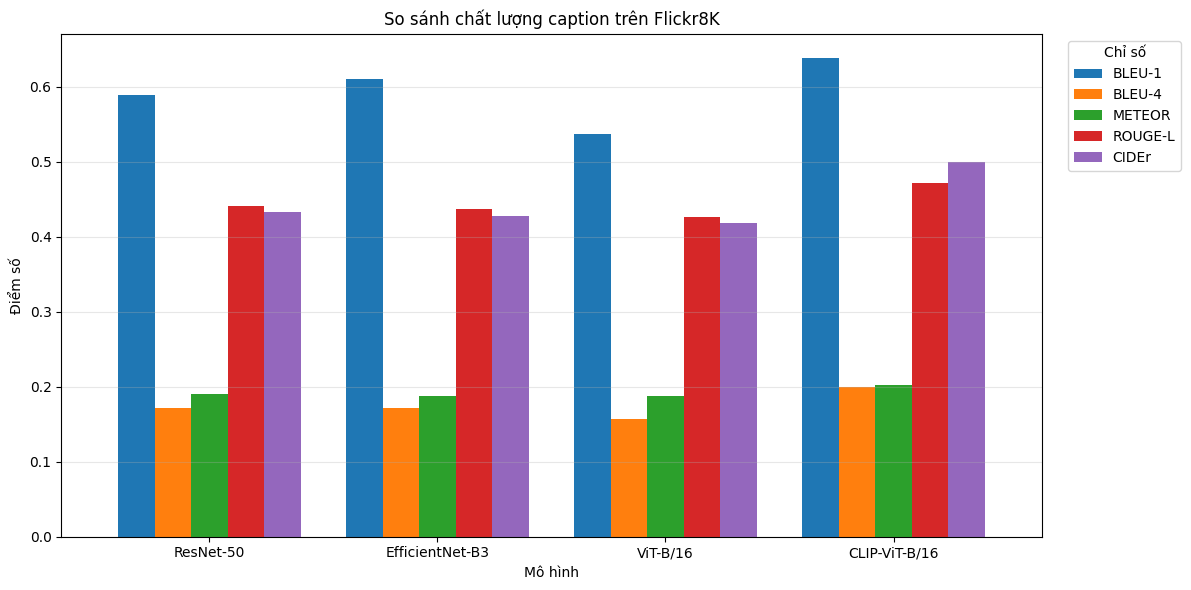

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/figures/four_models_metrics_comparison.png


In [142]:
import matplotlib.pyplot as plt

metric_plot_df = test_metric_df.set_index(
    "Mô hình"
)

ax = metric_plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title(
    "So sánh chất lượng caption trên Flickr8K"
)
ax.set_xlabel("Mô hình")
ax.set_ylabel("Điểm số")
ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(
    rotation=0
)
plt.legend(
    title="Chỉ số",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

metric_figure_path = (
    FIGURE_DIR /
    "four_models_metrics_comparison.png"
)

plt.savefig(
    metric_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu:", metric_figure_path)

13.8. Vẽ biểu đồ thời gian suy luận

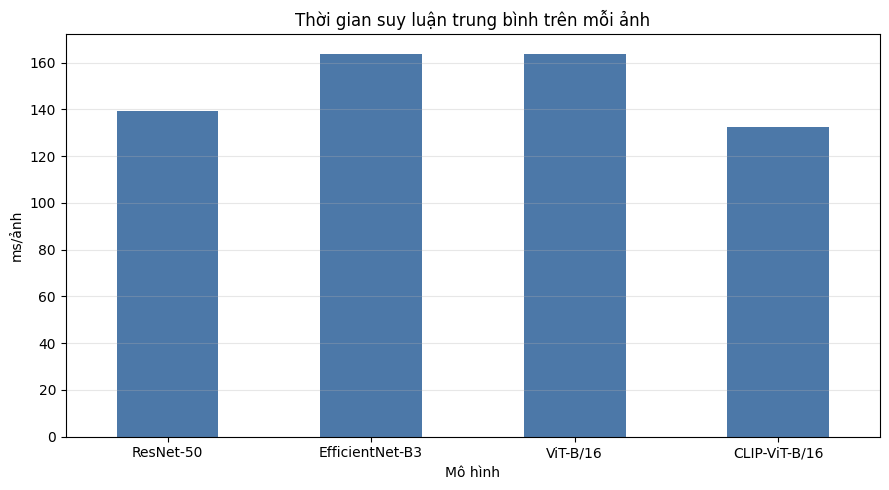

Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/figures/four_models_inference_time.png


In [143]:
time_plot_df = efficiency_df[
    [
        "Mô hình",
        "Suy luận trung bình (ms/ảnh)"
    ]
].set_index("Mô hình")

ax = time_plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    color="#4C78A8",
    legend=False
)

ax.set_title(
    "Thời gian suy luận trung bình trên mỗi ảnh"
)
ax.set_xlabel("Mô hình")
ax.set_ylabel("ms/ảnh")
ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=0)
plt.tight_layout()

inference_figure_path = (
    FIGURE_DIR /
    "four_models_inference_time.png"
)

plt.savefig(
    inference_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu:", inference_figure_path)

13.9. Tự động xác định model tốt nhất và nhanh nhất

In [144]:
best_cider_row = final_summary_df.loc[
    final_summary_df["CIDEr"].idxmax()
]

best_bleu4_row = final_summary_df.loc[
    final_summary_df["BLEU-4"].idxmax()
]

fastest_row = final_summary_df.loc[
    final_summary_df[
        "Suy luận trung bình (ms/ảnh)"
    ].idxmin()
]

shortest_training_row = final_summary_df.loc[
    final_summary_df[
        "Thời gian huấn luyện (s)"
    ].idxmin()
]

print("===== NHẬN XÉT TỰ ĐỘNG =====")

print(
    f"CIDEr cao nhất: {best_cider_row['Mô hình']} "
    f"({best_cider_row['CIDEr']:.6f})"
)

print(
    f"BLEU-4 cao nhất: {best_bleu4_row['Mô hình']} "
    f"({best_bleu4_row['BLEU-4']:.6f})"
)

print(
    f"Suy luận nhanh nhất: {fastest_row['Mô hình']} "
    f"({fastest_row['Suy luận trung bình (ms/ảnh)']:.2f} ms/ảnh)"
)

print(
    f"Huấn luyện decoder ngắn nhất: "
    f"{shortest_training_row['Mô hình']} "
    f"({shortest_training_row['Thời gian huấn luyện (s)']:.2f} giây)"
)

===== NHẬN XÉT TỰ ĐỘNG =====
CIDEr cao nhất: CLIP-ViT-B/16 (0.499591)
BLEU-4 cao nhất: CLIP-ViT-B/16 (0.199172)
Suy luận nhanh nhất: CLIP-ViT-B/16 (132.34 ms/ảnh)
Huấn luyện decoder ngắn nhất: CLIP-ViT-B/16 (66.12 giây)


#**GIẢI PHÓNG BỘ NHỚ**

In [78]:
del model
del loaded_model
del feature_pack
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [101]:
# MODEL_TO_RUN = "resnet50"
# MODEL_TO_RUN = "efficientnet_b3"
# MODEL_TO_RUN = "vit_b_16"
MODEL_TO_RUN = "clip_vit_b16"
# chạy lại 7.4, 8.5, 9.6, 10.1, 11.5 và 11.6

#**TỔNG HỢP**

In [113]:
import json
import pandas as pd

summary_rows = []

for model_name in MODEL_NAMES:
    metric_path = (
        METRIC_DIR /
        f"{model_name}_beam_metrics.json"
    )

    if not metric_path.exists():
        print("Chưa có:", metric_path)
        continue

    with open(
        metric_path,
        "r",
        encoding="utf-8"
    ) as f:
        result = json.load(f)

    total_seconds = (
        result["feature_extraction_seconds"]
        + result["training_seconds"]
    )

    summary_rows.append({
        "Mô hình": model_name,
        "Epoch tốt nhất": result["best_epoch"],
        "Training loss": result[
            "train_loss_at_best_epoch"
        ],
        "Validation loss": result[
            "validation_loss_at_best_epoch"
        ],
        "Thời gian trích feature (s)": result[
            "feature_extraction_seconds"
        ],
        "Thời gian train decoder (s)": result[
            "training_seconds"
        ],
        "Tổng thời gian (s)": total_seconds,
        "BLEU-1": result["BLEU-1"],
        "BLEU-4": result["BLEU-4"],
        "METEOR": result["METEOR"],
        "ROUGE-L": result["ROUGE-L"],
        "CIDEr": result["CIDEr"],
        "Suy luận trung bình/ảnh (s)": result[
            "average_seconds_per_image"
        ]
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = (
    METRIC_DIR /
    "four_models_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

display(summary_df)
print("Đã lưu:", summary_path)

Chưa có: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/efficientnet_b3_beam_metrics.json


,Mô hình,Epoch tốt nhất,Training loss,Validation loss,Thời gian trích feature (s),Thời gian train decoder (s),Tổng thời gian (s),BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,Suy luận trung bình/ảnh (s)
0,resnet50,4,3.036640,2.986582,168.595235,79.531170,248.126405,0.638417,0.199172,0.202404,0.47123,0.499591,0.167607
1,vit_b_16,4,3.080702,3.055468,147.316032,75.423933,222.739965,0.536406,0.157235,0.188135,0.42644,0.417896,0.145318
2,clip_vit_b16,4,3.036640,2.986582,155.599431,66.116060,221.715491,0.638417,0.199172,0.202404,0.47123,0.499591,0.127910


Đã lưu: /content/drive/MyDrive/KLCN/NguyenThanhDanh/metrics/four_models_summary.csv
